In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

credit_df = pd.read_csv("../data/raw/loan_approval.csv")
credit_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [2]:
# Dimensiones del dataset
credit_df.shape

# Tipos de datos
credit_df.info()

# Valores faltantes
credit_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [3]:
credit_df.columns #hay espacios al comienzo de cada variable, salvo la primera que es 'loan_id'

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [4]:
credit_df.columns = credit_df.columns.str.strip().str.lower()#Limpiamos los espacios
credit_df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [5]:
credit_df['loan_status'].value_counts(normalize=True)


 Approved    0.62216
 Rejected    0.37784
Name: loan_status, dtype: float64

**summary.md**

**El dataset presenta una distribución relativamente balanceada entre créditos aprobados (≈62%) y rechazados (≈38%). No se observa un desbalance severo, por lo que inicialmente no es necesario aplicar técnicas de balanceo de clases. Este aspecto se evaluará nuevamente en función de las métricas del modelo.**

In [6]:
credit_df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
# loan_id es un identificador único y no aporta valor predictivo
credit_df['loan_id'].nunique()

4269

In [8]:
# residential_assets_value (Valores negativos en activos residenciales)
# se hace la correccion en preprocessing

In [9]:
credit_df['residential_assets_value'].describe()

count    4.269000e+03
mean     7.472617e+06
std      6.503637e+06
min     -1.000000e+05
25%      2.200000e+06
50%      5.600000e+06
75%      1.130000e+07
max      2.910000e+07
Name: residential_assets_value, dtype: float64

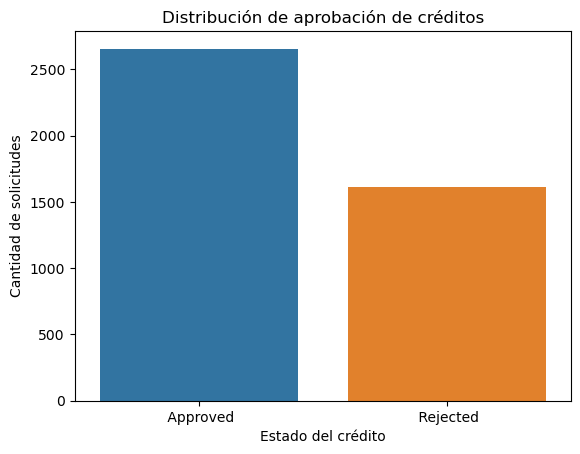

In [10]:
# Visualizamos la distribución del target (aprobado vs rechazado)
# Esto permite evaluar el balance de clases antes de entrenar el modelo
sns.countplot(x='loan_status', data=credit_df)
plt.title('Distribución de aprobación de créditos')
plt.xlabel('Estado del crédito')
plt.ylabel('Cantidad de solicitudes')
plt.show()

In [11]:
credit_df.dtypes

loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

In [20]:
# Definimos las columnas numéricas del dataset
# Estas variables representan ingresos, endeudamiento, score crediticio y activos
# Se utilizan para el análisis de correlación y EDA numérico
num_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value',
]



C:\Users\frann\AppData\Local\Temp\ipykernel_14268\3944874117.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = credit_df[num_cols + ['loan_status']].corr()


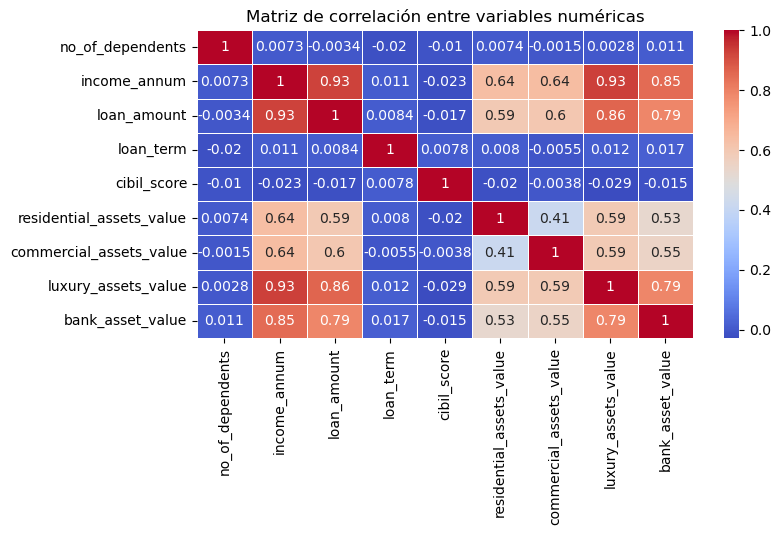

In [21]:
# Calculamos la matriz de correlación solo con columnas numéricas relevantes
# incluimos el target para ver su relación con las variables
corr_matrix = credit_df[num_cols + ['loan_status']].corr()

# Visualizamos la matriz de correlación
plt.figure(figsize=(8, 4))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    linewidths=0.5
)
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

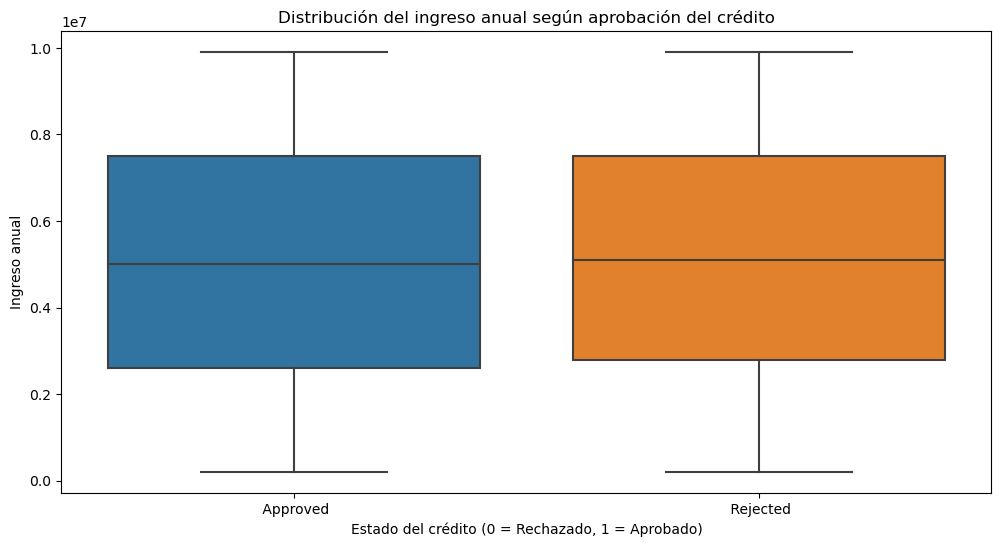

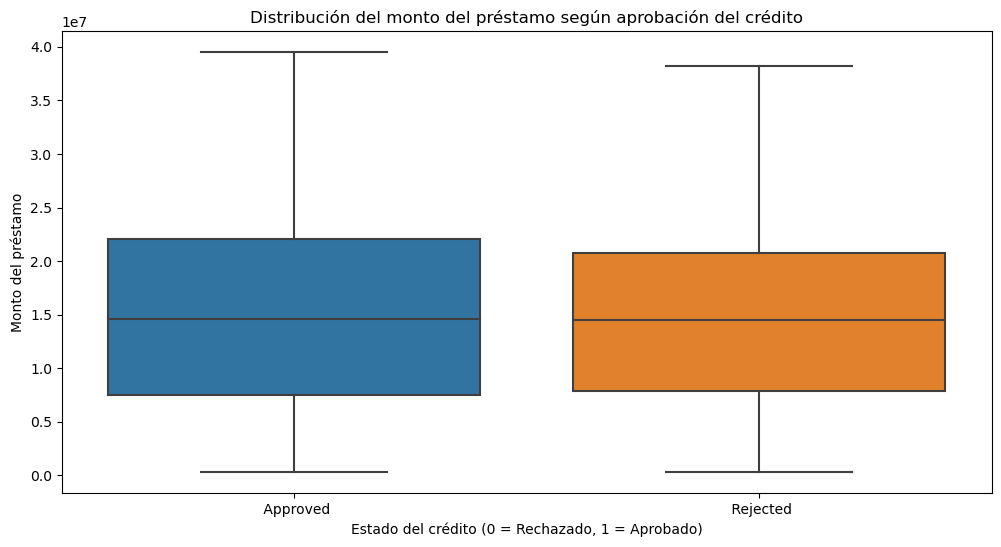

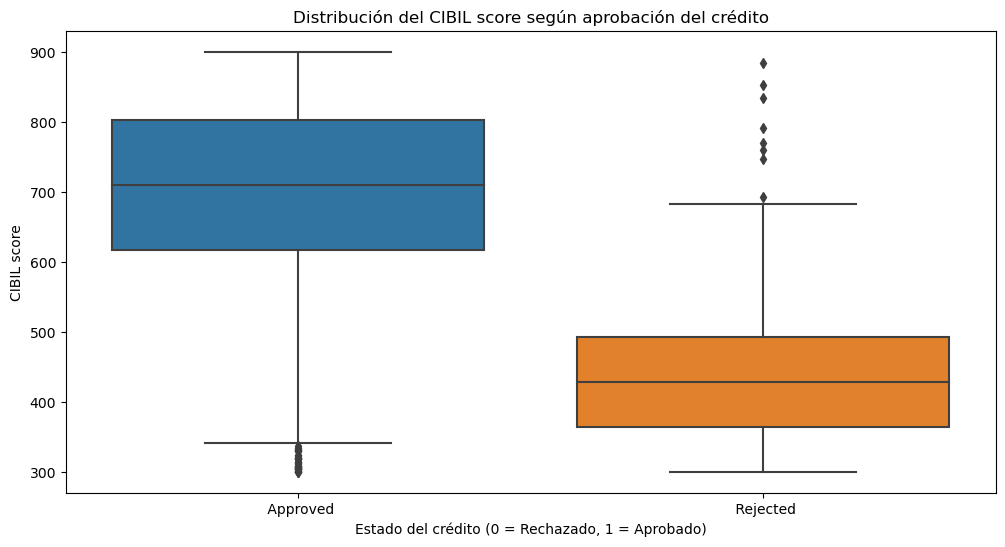

In [22]:
# Boxplot de ingresos vs estado del crédito
# Permite visualizar la distribución de ingresos según si el crédito fue aprobado o rechazado
plt.figure(figsize=(12,6))
sns.boxplot(x='loan_status', y='income_annum', data=credit_df)
plt.title('Distribución del ingreso anual según aprobación del crédito')
plt.xlabel('Estado del crédito (0 = Rechazado, 1 = Aprobado)')
plt.ylabel('Ingreso anual')
plt.show()

# Boxplot del monto del préstamo vs estado del crédito
plt.figure(figsize=(12,6))
sns.boxplot(x='loan_status', y='loan_amount', data=credit_df)
plt.title('Distribución del monto del préstamo según aprobación del crédito')
plt.xlabel('Estado del crédito (0 = Rechazado, 1 = Aprobado)')
plt.ylabel('Monto del préstamo')
plt.show()

# Boxplot del CIBIL score vs estado del crédito
plt.figure(figsize=(12,6))
sns.boxplot(x='loan_status', y='cibil_score', data=credit_df)
plt.title('Distribución del CIBIL score según aprobación del crédito')
plt.xlabel('Estado del crédito (0 = Rechazado, 1 = Aprobado)')
plt.ylabel('CIBIL score')
plt.show()

Hallazgos Principales:
Relación Ingresos-Préstamo (0.93): Existe una correlación positiva casi perfecta entre income_annum y loan_amount. Esto indica que el monto del préstamo otorgado está directamente ligado a la capacidad de generación de ingresos del solicitante.

Dependencia de Activos: Se observa una correlación alta (aprox. 0.93) entre el ingreso anual y el valor de los activos de lujo (luxury_assets_value). Asimismo, los activos bancarios y comerciales muestran una relación sólida con el monto del préstamo, lo que sugiere que funcionan como colateral o garantía.

Independencia del CIBIL Score: Notablemente, el cibil_score presenta una correlación cercana a cero con el resto de las variables financieras. Esto significa que tener altos ingresos o muchos activos no garantiza un buen historial crediticio; el score se comporta como una variable independiente y crítica para el modelo.

Factores Demográficos y Plazos: Variables como el número de dependientes (no_of_dependents) y el plazo del préstamo (loan_term) no muestran una relación lineal significativa con el nivel de riqueza o el monto solicitado.

Conclusión para el Modelo: Dado que income_annum y loan_amount están altamente correlacionados, presentan multicolinealidad. Para el entrenamiento de modelos de Machine Learning, esto sugiere que una de estas variables podría ser redundante o que ambas deben ser tratadas con cuidado para no sesgar el algoritmo.